<div class="notebook-nav"><a href="https://xingmei.io/notes/">&larr; All notes</a> &middot; <a href="https://xingmei.io/notes/generative_modeling_journey.html">Journey home</a></div>

# 1. The language of distributions

This journey studies **continuous-valued generative modeling**: distributions on spaces such as
$\mathbb{R}^d$. Images may be represented by dequantized pixel values or continuous latent variables.
We will not cover discrete data such as text-token sequences.

Every later chapter asks one continuous distribution to match another. This chapter fixes the shared
language for saying what those distributions are, which operations they expose, and how conditioning
works.

## 1. Random variables, samples, laws, and densities

Start with a random variable $X$ taking values in a sample space $\mathcal{X}$, such as
$\mathbb{R}^d$. These four objects are related, but they are not interchangeable:

| Name | Symbol | Role |
|:---|:---|:---|
| Random variable | $X$ | the random output before a value is observed |
| Realized sample | $x$ | one point produced by $X$ |
| Law / distribution | $P=\operatorname{Law}(X)$ | the probabilities assigned to regions of $\mathcal{X}$ |
| Density, when it exists | $p(x)$ | an optional function whose integral gives those probabilities |

The **law** of $X$ is the rule

$$
P(A)=\Pr(X\in A)
\tag{1.1}
$$

for every region $A\subseteq\mathcal{X}$. We write $X\sim P$ when $X$ has law $P$, and often use the
standard shorthand $x\sim P$ to mean "sample $x$ from $P$."

When the law has a density with respect to ordinary volume,

$$
\int_{\mathcal{X}}p(x)\,dx=1,
\qquad
P(A)=\int_A p(x)\,dx.
\tag{1.2}
$$

Capital letters such as $P$, $P_Z$, and $Q_\theta$ name laws. Matching lower-case letters such as
$p$, $p_Z$, and $q_\theta$ name their densities. Lower-case $x,y,z$ name realized points.

### Does every law have a density?

No - not with respect to ordinary volume on its ambient space. Let
$\Theta\sim\operatorname{Uniform}[0,2\pi)$ and

$$
X=(\cos\Theta,\sin\Theta)\in\mathbb{R}^2.
$$

$X$ varies continuously around the unit circle, but the circle has zero area in $\mathbb{R}^2$.
Therefore no ordinary function $p:\mathbb{R}^2\to[0,\infty)$ can recover this law through the area
integral in (1.2).

### A familiar continuous law

The basic continuous distribution is a Gaussian. In one dimension,

$$
X\sim\mathcal{N}(\mu,\sigma^2),
\qquad
\mathcal{N}(x;\mu,\sigma^2)
=\frac{1}{\sqrt{2\pi}\sigma}
\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right).
$$

The mean $\mu$ sets the center and the variance $\sigma^2$ sets the squared width. In $d$ dimensions,

$$
X\sim\mathcal{N}(\mu,\Sigma),
\qquad
\mathcal{N}(x;\mu,\Sigma)
=\frac{
\exp\!\left[-\tfrac12(x-\mu)^\top\Sigma^{-1}(x-\mu)\right]
}{
(2\pi)^{d/2}\det(\Sigma)^{1/2}
},
$$

where $\mu\in\mathbb{R}^d$ and the positive-definite covariance matrix
$\Sigma\in\mathbb{R}^{d\times d}$ controls scale and direction. The isotropic case
$\Sigma=\sigma^2I$ has the same variance in every direction.

A single Gaussian has one center. A **Gaussian mixture** combines $K$ of them:

$$
p(x)=\sum_{k=1}^K \pi_k\,\mathcal{N}(x;\mu_k,\Sigma_k),
\qquad
\pi_k\ge0,
\qquad
\sum_{k=1}^K\pi_k=1.
$$

Equivalently, draw a component index $C\sim\operatorname{Categorical}(\pi_1,\ldots,\pi_K)$ and then
draw $X\mid C=k\sim\mathcal{N}(\mu_k,\Sigma_k)$.

## 2. Sampling and density evaluation are different operations

A **sample equation** produces a sample point. For a one-dimensional Gaussian,

$$
X=\mu+\sigma Z,
\qquad
Z\sim\mathcal{N}(0,1).
\tag{1.3}
$$

A **density equation** evaluates an already supplied point:

$$
p(x)=\frac{1}{\sqrt{2\pi}\sigma}
\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right).
\tag{1.4}
$$

The first maps randomness to a sample. The second maps a point to a number. The same distribution may
offer both operations, only one, or neither in a convenient form. Much of generative modeling is shaped
by this asymmetry. For a Gaussian mixture, the sample equation first draws $C$ and then a Gaussian
sample from component $C$, while the density equation sums the weighted component densities at the
given point.

The code below shows both operations for a single Gaussian and for the eight-component ring mixture.

density integral: 1.0000
sample mean/std:  0.982 / 1.507


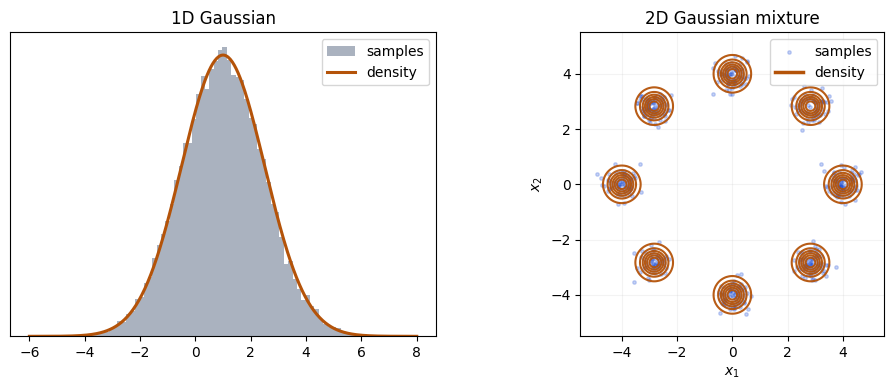

In [1]:
from __future__ import annotations
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

MU, SIGMA = 1.0, 1.5
N_MODES, RADIUS, MODE_STD = 8, 4.0, 0.30
angles = torch.arange(N_MODES) * (2 * math.pi / N_MODES)
centers = torch.stack([RADIUS * torch.cos(angles), RADIUS * torch.sin(angles)], dim=1)


def gaussian_sample(n: int) -> torch.Tensor:
    '''Draw n samples from N(MU, SIGMA^2).'''
    return MU + SIGMA * torch.randn(n)


def gaussian_density(x: torch.Tensor) -> torch.Tensor:
    '''Evaluate the normalized density of N(MU, SIGMA^2).'''
    normalizer = math.sqrt(2 * math.pi) * SIGMA
    return torch.exp(-((x - MU) ** 2) / (2 * SIGMA**2)) / normalizer


def mixture_sample(n: int) -> torch.Tensor:
    '''Draw n samples from the eight-component Gaussian ring mixture.'''
    component = torch.randint(0, N_MODES, (n,))
    return centers[component] + MODE_STD * torch.randn(n, 2)


def mixture_density(x: torch.Tensor) -> torch.Tensor:
    '''Evaluate the normalized density of the Gaussian ring mixture.'''
    offsets = x[..., None, :] - centers
    component_density = torch.exp(-offsets.square().sum(-1) / (2 * MODE_STD**2))
    component_density = component_density / (2 * math.pi * MODE_STD**2)
    return component_density.mean(-1)


samples = gaussian_sample(20_000)
grid = torch.linspace(-6, 8, 400)
density = gaussian_density(grid)
dx = grid[1] - grid[0]
ring_samples = mixture_sample(6_000)
plane = torch.linspace(-5.5, 5.5, 220)
gx, gy = torch.meshgrid(plane, plane, indexing="xy")
ring_density = mixture_density(torch.stack([gx, gy], dim=-1))

print(f"density integral: {(density.sum() * dx).item():.4f}")
print(f"sample mean/std:  {samples.mean().item():.3f} / {samples.std().item():.3f}")

fig, ax = plt.subplots(
    1,
    2,
    figsize=(10.4, 4.0),
    gridspec_kw={"width_ratios": [1.0, 1.35]},
)
ax[0].hist(samples.numpy(), bins=80, density=True, alpha=0.55, color="#64748b", label="samples")
ax[0].plot(grid.numpy(), density.numpy(), color="#b45309", lw=2.2, label="density")
ax[0].set_title("1D Gaussian")
ax[0].set_yticks([])
ax[0].legend()
levels = np.linspace(0, ring_density.max().item(), 14)
ax[1].contour(
    gx.numpy(),
    gy.numpy(),
    ring_density.numpy(),
    levels=levels[1::2],
    colors="#b45309",
    linewidths=1.5,
    alpha=0.95,
)
shown_ring_samples = ring_samples[:600]
ax[1].scatter(
    shown_ring_samples[:, 0].numpy(),
    shown_ring_samples[:, 1].numpy(),
    s=6,
    alpha=0.24,
    color="#1d4ed8",
    label="samples",
)
ax[1].plot([], [], color="#b45309", lw=2.5, label="density")
ax[1].legend()
ax[1].set_title("2D Gaussian mixture")
ax[1].set_aspect("equal")
ax[1].set_xlabel("$x_1$")
ax[1].set_ylabel("$x_2$")
ax[1].grid(alpha=0.15)
plt.tight_layout()
plt.show()

## 3. Source, generator, model, and target

The main journey begins from an easy **source** random variable,

$$
Z\sim P_Z,
\tag{1.5}
$$

and applies a parameterized generator,

$$
X_\theta=G_\theta(Z).
\tag{1.6}
$$

The generator is a function. Its random output has a law,

$$
Q_\theta=\operatorname{Law}(X_\theta)=(G_\theta)_\#P_Z,
\tag{1.7}
$$

called the **pushforward** of $P_Z$ through $G_\theta$. The notation means

$$
Q_\theta(A)
=P_Z\!\left(G_\theta^{-1}(A)\right)
=\Pr\!\left(G_\theta(Z)\in A\right).
\tag{1.8}
$$

Read it operationally: draw $Z$, apply $G_\theta$, and report the distribution of what comes out.

The **target** law is $P$. If $Y\sim P$, then $y$ is a target sample. Generative modeling adjusts
$\theta$ so that the model law $Q_\theta$ agrees with $P$. The network output $x_\theta=G_\theta(z)$ is one sample;
the pushforward $Q_\theta$ is the whole object being trained.

### When does a pushforward density exist?

If $G_\theta:\mathbb{R}^d\to\mathbb{R}^d$ is a differentiable bijection with a differentiable inverse
and nonsingular Jacobian, then

$$
q_\theta(x)
=p_Z\!\left(G_\theta^{-1}(x)\right)
\left|\det J_{G_\theta^{-1}}(x)\right|,
\tag{1.9}
$$

where $J_{G_\theta^{-1}}$ is the Jacobian matrix of the inverse map.

For a general neural generator, the inverse may not exist, the latent and data dimensions may differ,
or the determinant may be too expensive. The sample equation $X_\theta=G_\theta(Z)$ still works, while
$q_\theta(x)$ becomes unavailable. Such a model is called **implicit**: its law is defined by sampling
rather than by an evaluable likelihood.

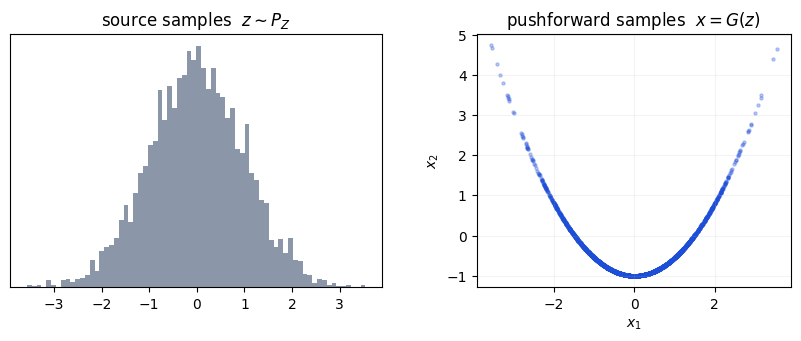

In [2]:
# A one-dimensional source pushed onto a curve in R^2.
# The model is easy to sample, but it has no ordinary density over the plane.
z = torch.randn(4_000)
model_samples = torch.stack([z, 0.45 * z**2 - 1.0], dim=1)

fig, ax = plt.subplots(1, 2, figsize=(8.4, 3.4))
ax[0].hist(z.numpy(), bins=70, density=True, color="#64748b", alpha=0.75)
ax[0].set_title(r"source samples  $z\sim P_Z$")
ax[0].set_yticks([])
ax[1].scatter(
    model_samples[:, 0].numpy(),
    model_samples[:, 1].numpy(),
    s=5,
    alpha=0.28,
    color="#1d4ed8",
)
ax[1].set_title(r"pushforward samples  $x=G(z)$")
ax[1].set_aspect("equal")
ax[1].set_xlabel("$x_1$")
ax[1].set_ylabel("$x_2$")
ax[1].grid(alpha=0.15)
plt.tight_layout()
plt.show()

## 4. The handles a distribution may expose

A law can be mathematically well defined while exposing only some of the following operations:

| Handle | Typical notation | Operation |
|:---|:---|:---|
| sample | $x\sim P$ | randomness $\longrightarrow$ point |
| normalized density | $p(x)$ or $\log p(x)$ | point $\longrightarrow$ likelihood |
| unnormalized density | $\tilde p(x)$ | point $\longrightarrow$ relative likelihood |
| Stein score | $\nabla_x\log p(x)$ | point $\longrightarrow$ uphill direction in sample space |
| differentiable sample | $x=G_\theta(z)$ | parameter change $\longrightarrow$ sample change |
| parameter score | $\nabla_\theta\log q_\theta(x)$ | parameter change $\longrightarrow$ log-density change |

### Unnormalized densities and the Stein score

An unnormalized density has the form

$$
p(x)=\frac{\tilde p(x)}{\mathcal{Z}_p},
\qquad
\mathcal{Z}_p=\int_{\mathcal{X}}\tilde p(x)\,dx.
\tag{1.10}
$$

The constant $\mathcal{Z}_p$ may be impossible to compute. Wherever $p(x)>0$, differentiating with
respect to the **sample** removes it:

$$
\nabla_x\log p(x)
=\nabla_x\log\tilde p(x).
\tag{1.11}
$$

This vector is the **Stein score**. It points toward increasing log-density and is a field over sample
space. For a standard Gaussian,

$$
\nabla_x\log p(x)=-x,
\tag{1.12}
$$

so every arrow points back toward the high-density center.

The **parameter score** is different:

$$
\nabla_\theta\log q_\theta(x).
\tag{1.13}
$$

Here the normalizer can depend on $\theta$, so it does not generally disappear. Always inspect the
subscript on $\nabla$: $\nabla_x$ moves through sample space; $\nabla_\theta$ moves through model
parameters.

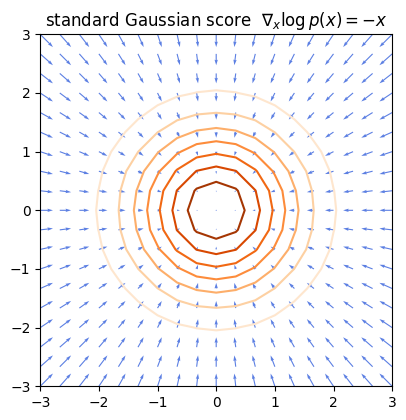

In [3]:
axis = torch.linspace(-3, 3, 19)
gx, gy = torch.meshgrid(axis, axis, indexing="xy")
points = torch.stack([gx, gy], dim=-1)
score = -points
density2d = torch.exp(-0.5 * (gx**2 + gy**2)) / (2 * math.pi)

fig, ax = plt.subplots(figsize=(4.8, 4.3))
ax.contour(gx.numpy(), gy.numpy(), density2d.numpy(), levels=8, cmap="Oranges")
ax.quiver(
    gx.numpy(),
    gy.numpy(),
    score[..., 0].numpy(),
    score[..., 1].numpy(),
    color="#1d4ed8",
    alpha=0.72,
)
ax.set_title(r"standard Gaussian score  $\nabla_x\log p(x)=-x$")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 5. Expectations, joint laws, and conditioning

For a scalar or vector statistic $f$,

$$
\mathbb{E}_{X\sim P}[f(X)]
=\int_{\mathcal{X}}f(x)\,p(x)\,dx.
\tag{1.14}
$$

With independent draws $x_1,\ldots,x_n\sim P$, Monte Carlo replaces the integral by

$$
\mathbb{E}_{X\sim P}[f(X)]
\approx
\frac{1}{n}\sum_{i=1}^n f(x_i).
\tag{1.15}
$$

The sample average is random but unbiased. This is why rewriting an objective as expectations over
available draws is so valuable: no density is needed.

### Joint, marginal, and conditional laws

A **joint law** $P_{X,Y}$ describes two random variables together. Its marginals $P_X$ and $P_Y$
describe either variable after the other is ignored. A **conditional law**
$P_{Y\mid X=x}$ keeps the observation $X=x$ fixed and describes how $Y$ varies among outcomes
compatible with it.

When the variables have densities, marginalization means integrating out one variable:

$$
p_X(x)=\int p_{X,Y}(x,y)\,dy.
\tag{1.16}
$$

Where $p_X(x)>0$, conditioning and Bayes' rule read

$$
p_{Y\mid X}(y\mid x)
=\frac{p_{X,Y}(x,y)}{p_X(x)}
=\frac{p_{X\mid Y}(x\mid y)\,p_Y(y)}{p_X(x)}.
\tag{1.17}
$$

Independence means the joint law is the product law,
$P_{X,Y}=P_X\otimes P_Y$. When densities exist this becomes
$p_{X,Y}(x,y)=p_X(x)p_Y(y)$, so observing $X$ does not change the law of $Y$.

### Conditional expectation and the tower rule

Let $Y$ be a random target and $X$ an observed random variable. Define

$$
m(x)=\mathbb{E}_{Y}[Y\mid X=x].
\tag{1.18}
$$

The random draw is $Y$; the conditional mean $m(x)$ is a **function of the observed value** $x$.

The **tower rule** says that averaging inside each conditional group and then averaging the groups
recovers the original average:

$$
\mathbb{E}_{X,Y}[h(X,Y)]
=
\mathbb{E}_{X}\!\left[
\mathbb{E}_{Y}[h(X,Y)\mid X]
\right].
\tag{1.19}
$$

Any function of $X$ is fixed inside the inner average, so

$$
\mathbb{E}_{Y}[g(X)\,Y\mid X]
=g(X)\,\mathbb{E}_{Y}[Y\mid X].
\tag{1.20}
$$

### Squared error learns a conditional mean

Let $m(X)=\mathbb{E}_{Y}[Y\mid X]$. For any predictor $u(X)$, expand the error around $m(X)$:

$$
\begin{aligned}
\lVert u(X)-Y\rVert^2
&=\lVert u(X)-m(X)\rVert^2+\lVert Y-m(X)\rVert^2\\
&\quad-2\bigl(u(X)-m(X)\bigr)^\top\bigl(Y-m(X)\bigr).
\end{aligned}
$$

Given $X$, the first factor in the cross term is fixed, while
$\mathbb{E}_{Y}[Y-m(X)\mid X]=0$. The cross term therefore averages to zero, leaving

$$
\begin{aligned}
\mathbb{E}_{X,Y}\!\left[\lVert u(X)-Y\rVert^2\right]
&=
\mathbb{E}_{X}\!\left[\lVert u(X)-m(X)\rVert^2\right]\\
&\quad+
\mathbb{E}_{X}\!\left[
\mathbb{E}_{Y}\!\left[\lVert Y-m(X)\rVert^2\mid X\right]
\right].
\end{aligned}
\tag{1.21}
$$

Assuming a finite conditional second moment, the second line contains no $u$. Therefore the unique
pointwise minimizer, up to values of $x$ outside the support of $P_X$, is

$$
u^\star(x)=m(x)=\mathbb{E}_{Y}[Y\mid X=x].
\tag{1.22}
$$

The irreducible conditional spread raises the minimum loss but does not move its minimizer. This one
identity underlies denoising regression, data prediction, noise prediction, and flow matching.

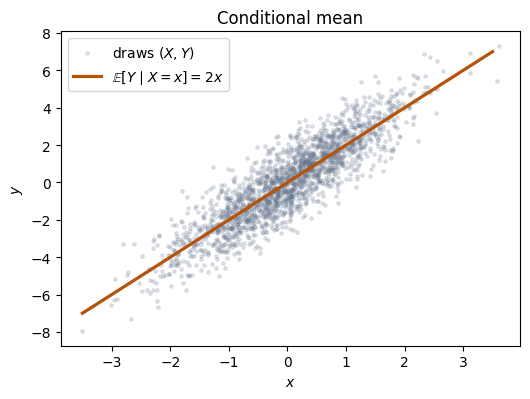

In [4]:
# Y = 2X + E with independent zero-mean noise, so E[Y | X=x] = 2x.
n = 12_000
x = torch.randn(n)
y = 2 * x + torch.randn(n)

fig, ax = plt.subplots(figsize=(5.4, 4.1))
keep = torch.randperm(n)[:2_000]
ax.scatter(
    x[keep].numpy(),
    y[keep].numpy(),
    s=6,
    alpha=0.18,
    color="#64748b",
    label="draws $(X,Y)$",
)
line = torch.linspace(-3.5, 3.5, 200)
ax.plot(line.numpy(), (2 * line).numpy(), color="#b45309", lw=2.3, label=r"$\mathbb{E}[Y\mid X=x]=2x$")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")
ax.set_title("Conditional mean")
ax.legend()
plt.tight_layout()
plt.show()

## 6. The reusable dictionary

| Symbol | Meaning |
|:---|:---|
| $Z,z,P_Z,p_Z$ | source random variable, one source draw, source law, source density |
| $G_\theta$ | parameterized generator or sampler map |
| $X_\theta=G_\theta(Z)$ | random model output |
| $Q_\theta=(G_\theta)_\#P_Z$ | model law induced by the generator |
| $Y,y,P,p$ | target random variable, one target draw, target law, target density |
| $\tilde p$, $\mathcal{Z}_p$ in (1.10) | unnormalized density and its normalizing constant |
| $\nabla_x\log p$ | Stein score: a vector field over sample space |
| $\nabla_\theta\log q_\theta$ | parameter score |
| $\mathbb{E}_{X\sim P}[f(X)]$ | expectation of $f(X)$ when $X$ follows the law $P$ |
| $P_{X,Y}$ | joint law of two random variables |
| $P_{Y\mid X=x}$ | conditional law of $Y$ given an observed value $X=x$ |
| $m(x)=\mathbb{E}_{Y}[Y\mid X=x]$ | conditional mean as a function of the observation |

<div class="notebook-footer"><a href="https://xingmei.io/notes/generative_modeling_journey.html">Generative modeling: a gentle journey with distribution matching</a> &middot; Chapter 1 of 20</div>